# Multi-Class Logistic Regression

Hoe kan je niet-binaire classificatie uitvoeren met Logistieke Regressie?  Dit proces is bijna hetzelfde als met binaire classificatie.  We gaan even een eenvoudige gegevensset doorlopen en kijken hoe we LogisticRegression kunnen gebruiken met een handmatige GridSearchCV in plaats van een LogisticRegressionCV.

## Imports

In [1]:
import sklearn
sklearn.__version__

'1.8.0'

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.__version__

'0.13.2'

## Data

We zullen werken met de klassieke Iris-gegevensset. De Iris-bloemgegevensset of Fisher's Iris-gegevensset is een multivariate gegevensset geïntroduceerd door de Britse statisticus, eugeneticus en bioloog Ronald Fisher in zijn artikel uit 1936 'The use of multiple measurements in taxonomic problems' als een voorbeeld van lineaire discriminantanalyse.

Volledige details: https://en.wikipedia.org/wiki/Iris_flower_data_set

Sepal (Kelkblad):

Kelkbladen zijn de buitenste delen van de bloembodem die de bloem beschermen wanneer deze in knop staat. Ze liggen meestal onder de bloemblaadjes en kunnen groen of gekleurd zijn.
In de Iris dataset zijn er twee metingen met betrekking tot de kelkbladen:
Sepal Length (Kelkblad Lengte): De lengte van het kelkblad.
Sepal Width (Kelkblad Breedte): De breedte van het kelkblad.
Petal (Bloemblad):

Bloemblaadjes zijn de gekleurde delen van een bloem die meestal zichtbaar zijn en die insecten aantrekken voor bestuiving. Ze zijn vaak helder en opvallend van kleur.
In de Iris dataset zijn er ook twee metingen met betrekking tot de bloemblaadjes:
Petal Length (Bloemblad Lengte): De lengte van het bloemblad.
Petal Width (Bloemblad Breedte): De breedte van het bloemblad.
Deze vier kenmerken (kelkblad lengte en breedte, en bloemblad lengte en breedte) worden gebruikt in de Iris dataset om drie soorten Iris-bloemen te classificeren: Setosa, Versicolor en Virginica. Het is interessant op te merken dat op basis van deze vier kenmerken, machine learning modellen in staat zijn om met aanzienlijke nauwkeurigheid onderscheid te maken tussen de drie soorten.

In [ ]:
df = pd.read_csv('../data/iris.csv')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Verkennende Gegevensanalyse en Visualisatie

Voel je vrij om de gegevens verder zelf te verkennen.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: xlabel='species', ylabel='count'>

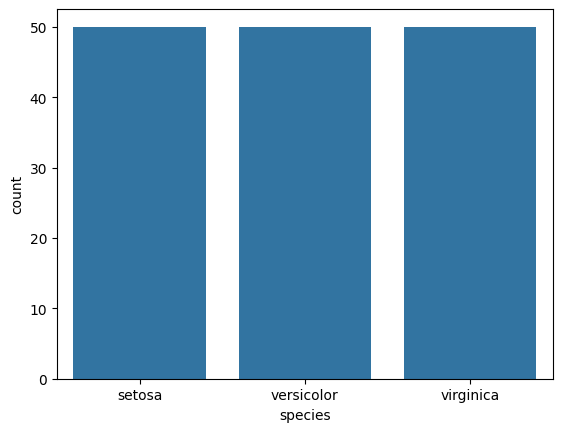

In [8]:
# sns.countplot(x=df['species'])
sns.countplot(x='species', data=df)

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

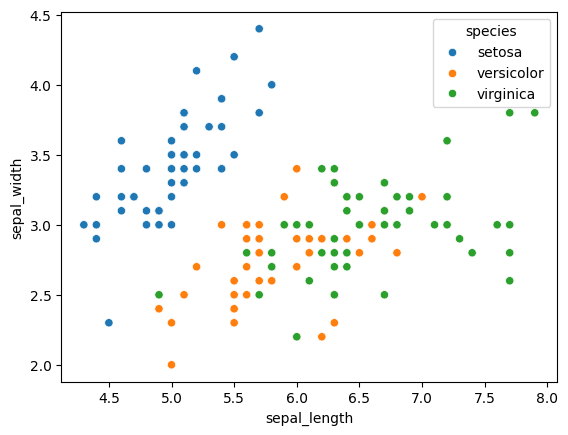

In [9]:
sns.scatterplot(x='sepal_length',y='sepal_width',data=df,hue='species')

<Axes: xlabel='petal_length', ylabel='petal_width'>

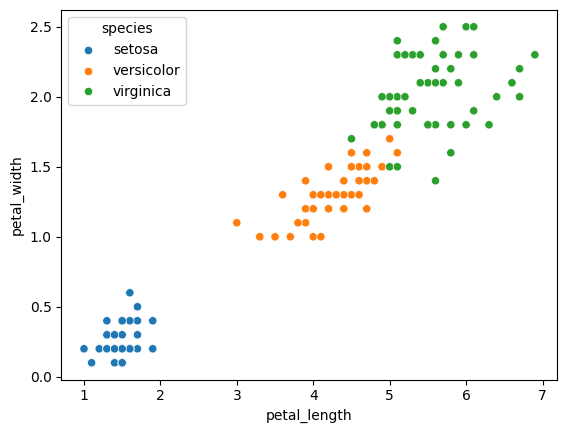

In [10]:
sns.scatterplot(x='petal_length',y='petal_width',data=df,hue='species')

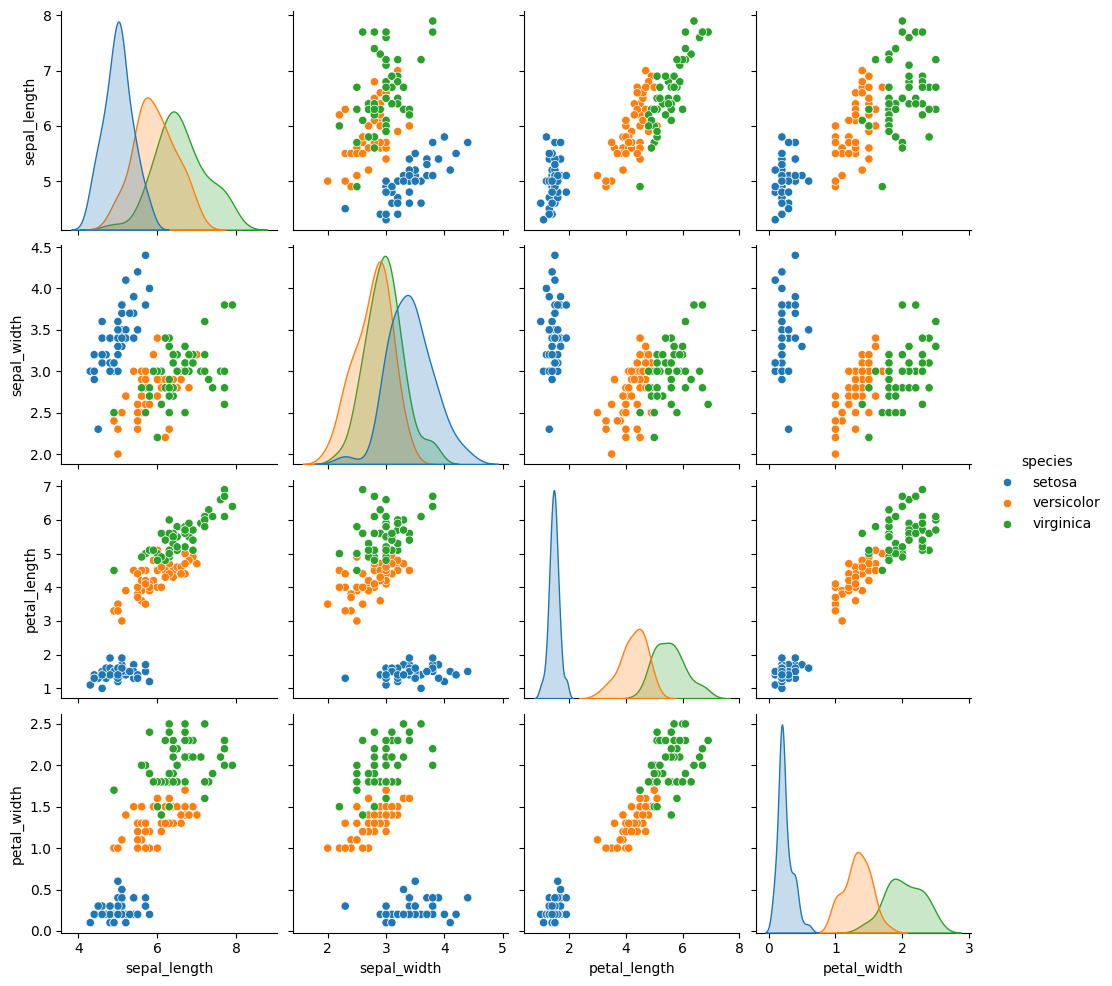

In [11]:
sns.pairplot(df,hue='species')

<Axes: >

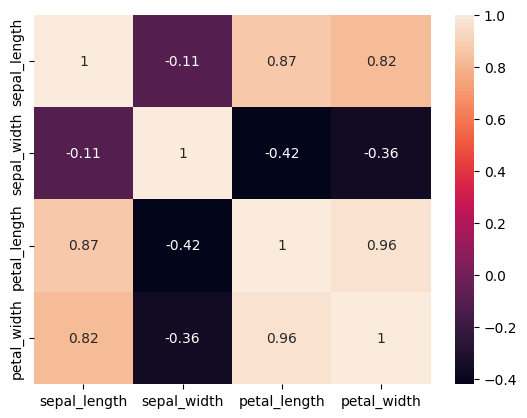

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [13]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

C:\Users\Cursist\AppData\Local\Temp\ipykernel_20012\425743021.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  copied_df['species'] = copied_df['species'].replace(mapping)


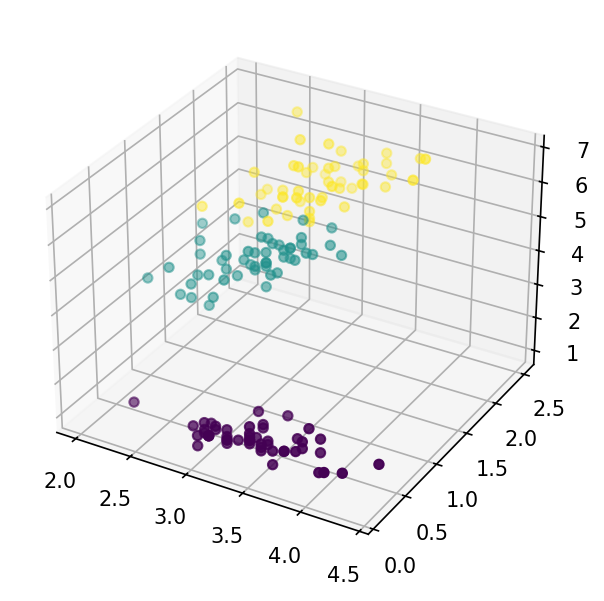

In [ ]:
copied_df = df.copy()

mapping =   {
            'setosa': 0,
            'versicolor': 1,
            'virginica': 2
            }
copied_df['species'] = copied_df['species'].replace(mapping)

fig = plt.figure(dpi=150)
ax = fig.add_subplot(projection='3d') # interesting!
ax.scatter(copied_df['sepal_width'],copied_df['petal_width'],copied_df['petal_length'],c=copied_df['species'])

### Train | Test Split and Scaling

In [15]:
X = df.drop('species', axis=1)
y = df['species']  # je moet voor het label geen one hot encoding of dergelijke toepassen: sklearn kan hiermee overweg voor Log Reg

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [18]:
scaler = StandardScaler()

In [19]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Multi-Class Logistic Regression Model

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
from sklearn.model_selection import GridSearchCV

In [25]:
# Depending on warnings you may need to adjust max iterations allowed 
# Or experiment with different solvers
log_model = LogisticRegression(solver='saga', max_iter=5000, verbose=0)

### GridSearch voor selectie van de beste Hyper-Parameters

De hoofdparameters zijn de regularization penalty en regularization C value ("Complexity").

In [32]:
# Penalty Type
# penalty = ['l1', 'l2', 'elasticnet']
l1_ratio = np.linspace(0, 1, 20)
C = np.logspace(0, 10, 20)  # logaritmic spacing aanbevolen!
           
param_grid = {'l1_ratio': l1_ratio,
              'C': C
             }

In [34]:
grid_model = GridSearchCV(log_model,param_grid=param_grid)

In [35]:
grid_model.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+10]), 'l1_ratio': array([0. ..., 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [36]:
grid_model.best_params_

{'C': np.float64(37.926901907322495), 'l1_ratio': np.float64(0.0)}

{'C': 11.28837891684689, 'penalty': 'l1'}

### Model Performance voor Classificatie

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [38]:
y_pred = grid_model.predict(scaled_X_test)

In [39]:
y_pred_proba = grid_model.predict_proba(scaled_X_test)

In [40]:
y_pred

array(['setosa', 'setosa', 'setosa', 'virginica', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'setosa', 'virginica', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'setosa', 'setosa',
       'virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'versicolor', 'versicolor', 'versicolor'], dtype=object)

array(['setosa', 'setosa', 'setosa', 'virginica', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'setosa', 'virginica', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'setosa', 'setosa',
       'virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'versicolor', 'versicolor', 'versicolor'], dtype=object)

In [ ]:
sum(y_pred_proba[2])

np.float64(0.9999999999999999)

In [42]:
accuracy_score(y_test,y_pred)

1.0

0.9736842105263158

In [43]:
confusion_matrix(y_test, y_pred)

array([[10,  0,  0],
       [ 0, 17,  0],
       [ 0,  0, 11]])

array([[10,  0,  0],
       [ 0, 17,  0],
       [ 0,  1, 10]], dtype=int64)

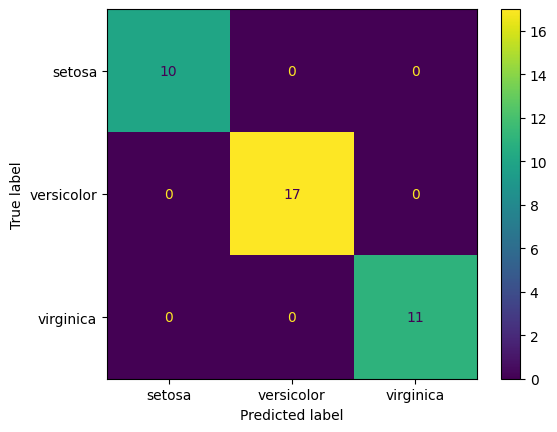

In [44]:
cm = confusion_matrix(y_test, y_pred, labels=grid_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=grid_model.classes_)
disp.plot()

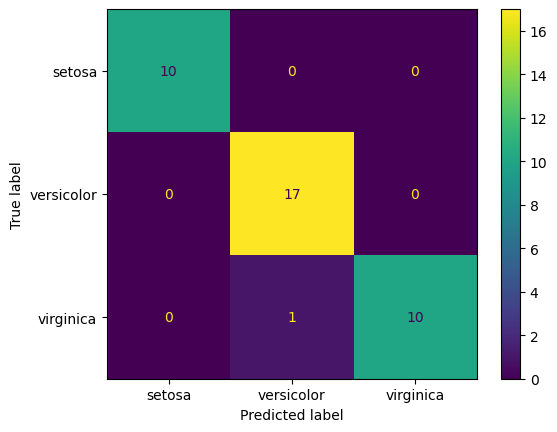

In [34]:
cm = confusion_matrix(y_test, y_pred, labels=grid_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=grid_model.classes_)
disp.plot()

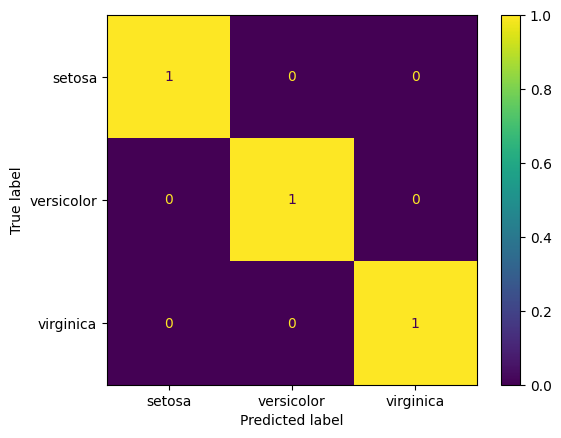

In [45]:
cm = confusion_matrix(y_test, y_pred, labels=grid_model.classes_, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=grid_model.classes_)
disp.plot()

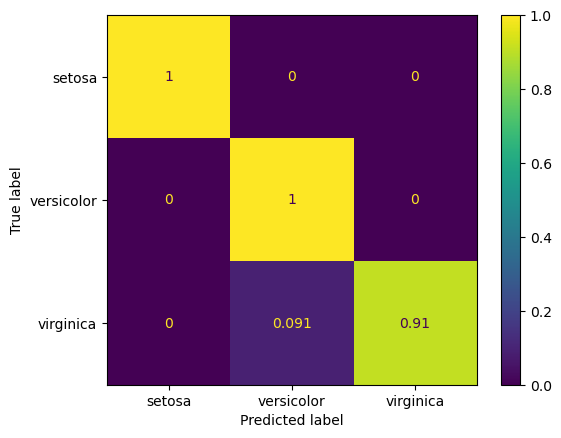

In [35]:
cm = confusion_matrix(y_test, y_pred, labels=grid_model.classes_, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=grid_model.classes_)
disp.plot()

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        17
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.94      1.00      0.97        17
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



## Evaluatie curves en AUC

**We moeten handmatig de grafieken maken voor een multi-class situatie. Gelukkig heeft de documentatie van Scikit-learn hier al veel voorbeelden van.**

Bron: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

Hieronder kan je een functie vinden die dit automatisch doet: een ROC per klasse maken en plotten.

In [47]:
from sklearn.metrics import roc_curve, auc

In [48]:
def plot_multiclass_roc(clf, X_test, y_test, n_classes, figsize=(5,5)):
    y_score = clf.decision_function(X_test)

    # structures
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # calculate dummies once
    y_test_dummies = pd.get_dummies(y_test, drop_first=False).values
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_dummies[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # roc for each class
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver operating characteristic example')
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f) for label %i' % (roc_auc[i], i))
    ax.legend(loc="best")
    ax.grid(alpha=.4)
    sns.despine()
    plt.show()

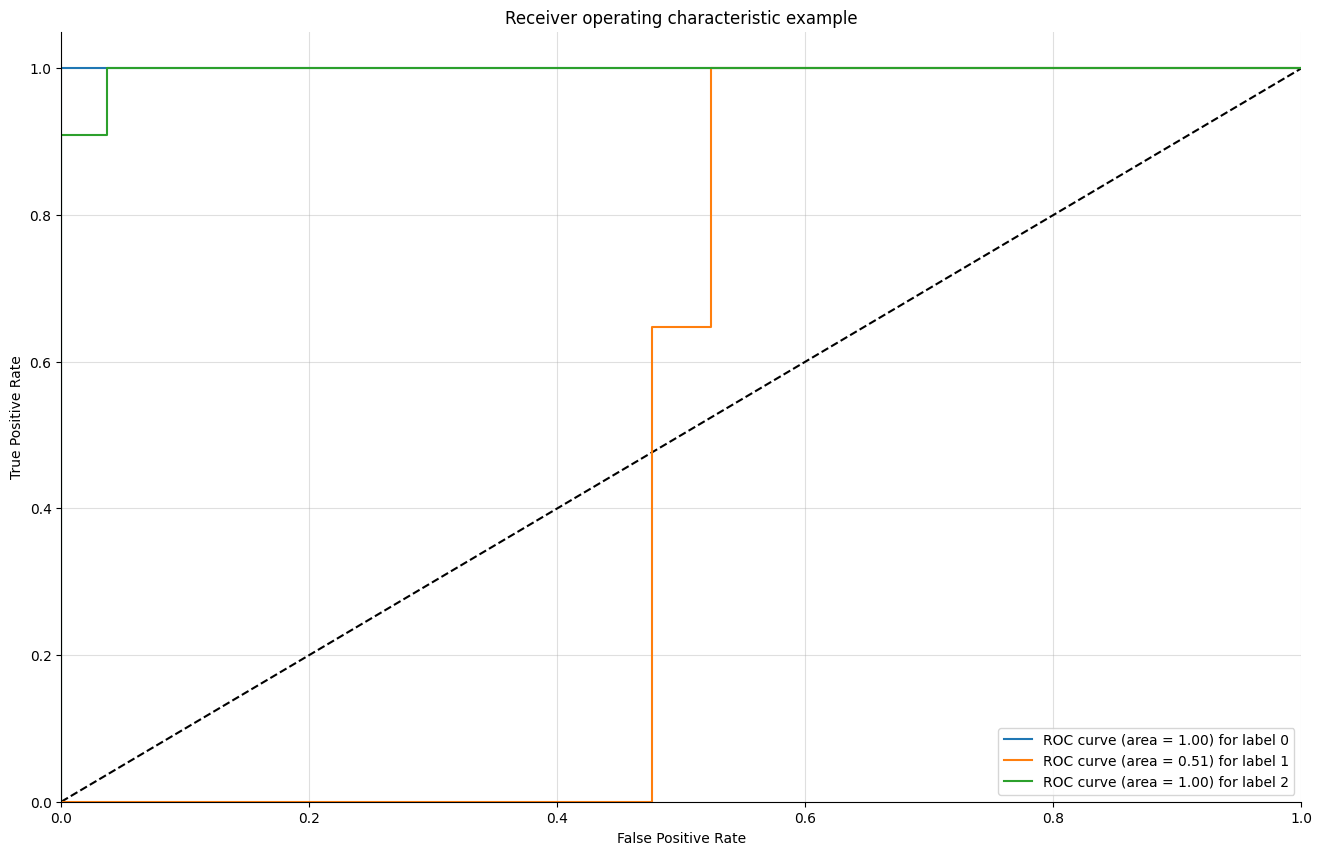

In [49]:
plot_multiclass_roc(grid_model, scaled_X_test, y_test, n_classes=3, figsize=(16, 10))

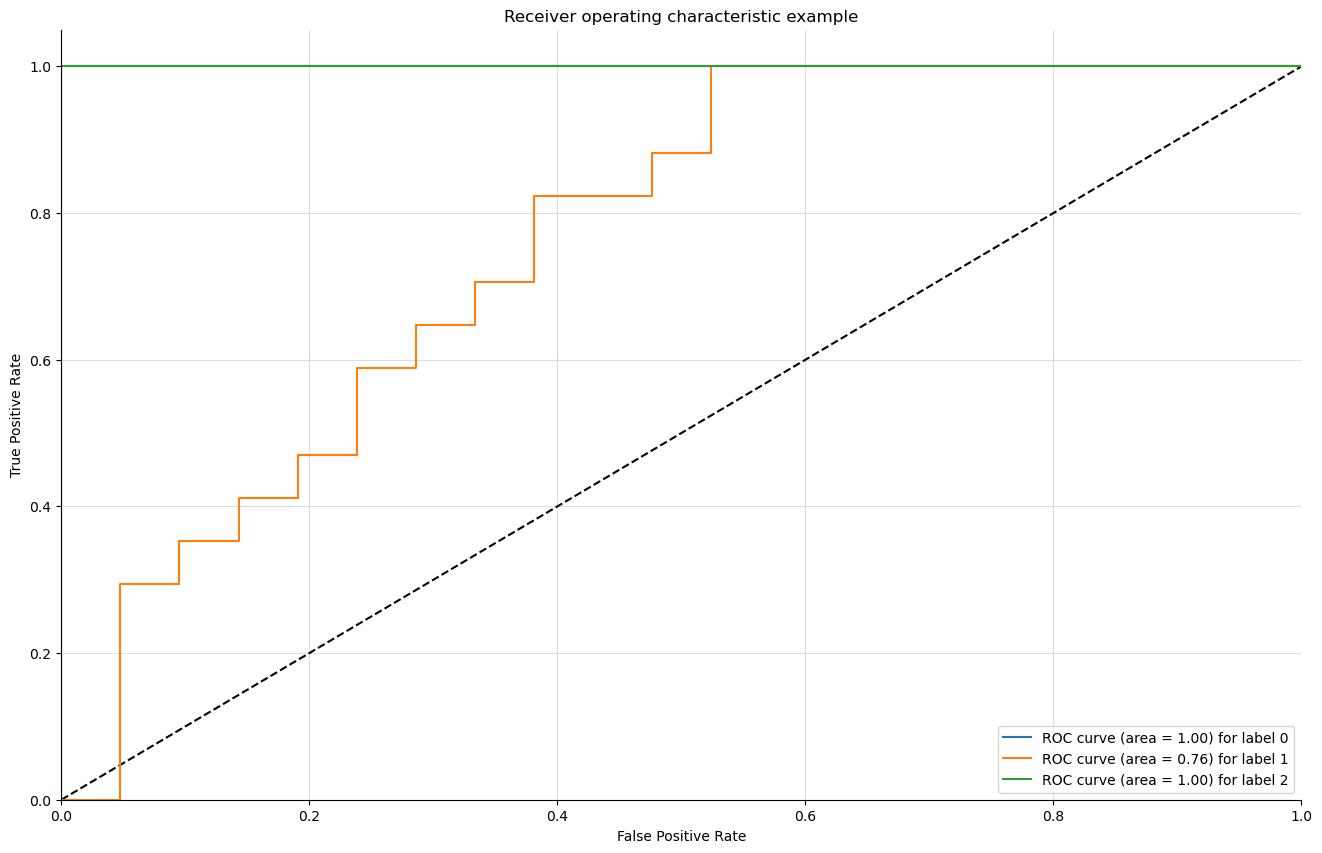

### Keuze van en interactie tussen de hyperparameters 

!! Dit is geen exacte wetenschap.  Enkele items die de keuzes kunnen bepalen zijn:
-grootte van je dataset  
-indien je geen goed resultaat krijgt kan je proberen het model complexer te laten worden.  Dit kan middels polynomial featers **of** een hogere C-waarde.  Indien je model niet meer convergeert hierdoor, kan je max_iter verhogen.  
-indien je gaat voor polynomial features, dan zal je model complexer worden.  Wellicht kan je dan C verlagen om het model te regulariseren.  
-de solver op zijn beurt zal dan bepalend zijn voor de soort regularisatie: geen, L1, L2 of elasticnet.  Indien je na Polynomialfeatures teveel features hebt, zal L1 met de mogelijkheid van feature selection wellicht handig zijn

![schema voor Logistieke Regressie Hyperparameter keuze](Logreg.png)


------
------